In [1]:
"""
Can also just spin up vLLM server with:

vllm serve deepseek-ai/DeepSeek-V2-Lite-Chat \
  --dtype auto \
  --max-model-len 4096 \
  --gpu-memory-utilization 0.85 \
  --max-num-seqs 16 \
  --tensor-parallel-size 2 --data-parallel-size 1 --enable-expert-parallel --enable-eplb
  
and also profile with:

vllm bench serve \
  --backend vllm \
  --model deepseek-ai/DeepSeek-V2-Lite-Chat \
  --dataset-name random \
  --num-prompts 50 \
  --request-rate 10 \
  --result-filename metrics.json
  
"""

'\nCan also just spin up vLLM server with:\n\nvllm serve deepseek-ai/DeepSeek-V2-Lite-Chat   --dtype auto   --max-model-len 4096   --gpu-memory-utilization 0.85   --max-num-seqs 16   --tensor-parallel-size 2 --data-parallel-size 1 --enable-expert-parallel --enable-eplb\n  \nand also profile with:\n\nvllm bench serve   --backend vllm   --model deepseek-ai/DeepSeek-V2-Lite-Chat   --dataset-name random   --num-prompts 50   --request-rate 10   --result-filename metrics.json\n  \n'

In [2]:
#%pip install openai
#%pip install typing-extensions
#%pip install matplotlib seaborn
#%pip install datasets transformers==4.38.2
#%pip install torch
#%pip install vllm
#%pip install --upgrade transformers

In [3]:
from experiments_vllm import *
from data import *
from transformers import AutoTokenizer

In [4]:
# Set seeds
seed = 43
torch.manual_seed(seed);

In [5]:
# Configuration
# For full dataset: n_samples = 15000, max_new_tokens = 100, batch_size = 16
model = "deepseek-ai/DeepSeek-V2-Lite-Chat"
port = 8000
n_samples = 1000
max_new_tokens = 100
max_model_len = 4096
gpu_memory_utilization = 0.85
n_gpus = 4
enable_expert_parallel = True
enable_prefix_caching = True
batch_size = 256
n_warmup_samples = 10
n_subjects = 10
n_repeat_prompts = 10
prompt_reps = 10 # Repeat prompts within a single request in order to inflate prefill

In [6]:
# Select prompts
sample_prompts = [
    "Explain the theory of relativity in simple terms.",
    "Write a python script to scrape a website.",
    "What are the benefits of MoE (Mixture of Experts) architectures?",
    "Tell me a short sci-fi story about a sentient coffee machine.",
    "Summarize the history of the Roman Empire in 3 paragraphs."
]

# Use MMLU questions
dataset = get_data_mmlu(n_samples=n_samples, shuffle_seed=seed)
mmlu_prompts = format_prompts_mmlu(dataset, prompt_reps=prompt_reps)

Streaming cais/mmlu (all) (samples: 1000)...


In [7]:
# Run experiment over generalized MMLU questions
overall_results, avg_tpot = await run_experiment_vllm_throughput(model,
                                                         mmlu_prompts,
                                                         seed=seed,
                                                         max_new_tokens=max_new_tokens,
                                                         max_model_len=max_model_len,
                                                         batch_size=batch_size,
                                                         concurrency_limit=batch_size*4,
                                                         gpu_memory_utilization=gpu_memory_utilization,
                                                         n_gpus=n_gpus,
                                                         n_warmup_samples=n_warmup_samples,
                                                         print_output=False,
                                                         enable_expert_parallel=enable_expert_parallel,
                                                         enable_prefix_caching=enable_prefix_caching)

Starting vLLM server for deepseek-ai/DeepSeek-V2-Lite-Chat...
Waiting for server to initialize ...
(APIServer pid=45686) INFO 06-08 12:52:41 [utils.py:344] 
(APIServer pid=45686) INFO 06-08 12:52:41 [utils.py:344]        █     █     █▄   ▄█
(APIServer pid=45686) INFO 06-08 12:52:41 [utils.py:344]  ▄▄ ▄█ █     █     █ ▀▄▀ █  version 0.22.1
(APIServer pid=45686) INFO 06-08 12:52:41 [utils.py:344]   █▄█▀ █     █     █     █  model   deepseek-ai/DeepSeek-V2-Lite-Chat
(APIServer pid=45686) INFO 06-08 12:52:41 [utils.py:344]    ▀▀  ▀▀▀▀▀ ▀▀▀▀▀ ▀     ▀
(APIServer pid=45686) INFO 06-08 12:52:41 [utils.py:344] 
(APIServer pid=45686) INFO 06-08 12:52:41 [utils.py:278] non-default args: {'model_tag': 'deepseek-ai/DeepSeek-V2-Lite-Chat', 'model': 'deepseek-ai/DeepSeek-V2-Lite-Chat', 'seed': 43, 'max_model_len': 4096, 'override_generation_config': {'temperature': 0.0}, 'tensor_parallel_size': 4, 'enable_expert_parallel': True, 'gpu_memory_utilization': 0.85, 'enable_prefix_caching': True, 'max_num_

(APIServer pid=45686) Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.


(APIServer pid=45686) INFO 06-08 12:52:42 [model.py:617] Resolved architecture: DeepseekV2ForCausalLM
(APIServer pid=45686) INFO 06-08 12:52:42 [model.py:1752] Using max model len 4096
(APIServer pid=45686) INFO 06-08 12:52:42 [vllm.py:977] Asynchronous scheduling is enabled.
(APIServer pid=45686) INFO 06-08 12:52:42 [kernel.py:270] Final IR op priority after setting platform defaults: IrOpPriorityConfig(rms_norm=['native'], fused_add_rms_norm=['native'])
(EngineCore pid=45904) INFO 06-08 12:52:49 [core.py:112] Initializing a V1 LLM engine (v0.22.1) with config: model='deepseek-ai/DeepSeek-V2-Lite-Chat', speculative_config=None, tokenizer='deepseek-ai/DeepSeek-V2-Lite-Chat', skip_tokenizer_init=False, tokenizer_mode=auto, revision=None, tokenizer_revision=None, trust_remote_code=False, dtype=torch.bfloat16, max_seq_len=4096, download_dir=None, load_format=auto, tensor_parallel_size=4, pipeline_parallel_size=1, data_parallel_size=1, decode_context_parallel_size=1, dcp_comm_backend=ag_rs

(Worker_TP1_EP1 pid=46103) Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.
Loading safetensors checkpoint shards:   0% Completed | 0/4 [00:00<?, ?it/s]
(Worker_TP2_EP2 pid=46104) Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.


(Worker_TP0_EP0 pid=46102) INFO 06-08 12:52:59 [weight_utils.py:922] Filesystem type for checkpoints: OVERLAY. Checkpoint size: 29.26 GiB. Available RAM: 175.00 GiB.
(Worker_TP0_EP0 pid=46102) INFO 06-08 12:52:59 [weight_utils.py:945] Auto-prefetch is disabled because the filesystem (OVERLAY) is not a recognized network FS (NFS/Lustre). If you want to force prefetching, start vLLM with --safetensors-load-strategy=prefetch.


...

(APIServer pid=45686) INFO:     Started server process [45686]
(APIServer pid=45686) INFO:     Waiting for application startup.
(APIServer pid=45686) INFO:     Application startup complete.


(APIServer pid=45686) INFO:     127.0.0.1:47518 - "GET /v1/models HTTP/1.1" 200 OK
Server is ready!
Sending batch of 10 concurrent requests...
(APIServer pid=45686) INFO:     127.0.0.1:47524 - "POST /v1/chat/completions HTTP/1.1" 200 OK
(APIServer pid=45686) INFO:     127.0.0.1:47532 - "POST /v1/chat/completions HTTP/1.1" 200 OK
(APIServer pid=45686) INFO:     127.0.0.1:47540 - "POST /v1/chat/completions HTTP/1.1" 200 OK
(APIServer pid=45686) INFO:     127.0.0.1:47550 - "POST /v1/chat/completions HTTP/1.1" 200 OK
(APIServer pid=45686) INFO:     127.0.0.1:47558 - "POST /v1/chat/completions HTTP/1.1" 200 OK
(APIServer pid=45686) INFO:     127.0.0.1:47568 - "POST /v1/chat/completions HTTP/1.1" 200 OK
(APIServer pid=45686) INFO:     127.0.0.1:47576 - "POST /v1/chat/completions HTTP/1.1" 200 OK
(APIServer pid=45686) INFO:     127.0.0.1:47590 - "POST /v1/chat/completions HTTP/1.1" 200 OK
(APIServer pid=45686) INFO:     127.0.0.1:47600 - "POST /v1/chat/completions HTTP/1.1" 200 OK
(APIServer 

(APIServer pid=45686) INFO:     Shutting down
(APIServer pid=45686) INFO:     Waiting for application shutdown.
(APIServer pid=45686) INFO:     Application shutdown complete.


Server successfully shut down.


/usr/lib/python3.11/multiprocessing/resource_tracker.py:254: UserWarning: resource_tracker: There appear to be 4 leaked semaphore objects to clean up at shutdown
  warnings.warn('resource_tracker: There appear to be %d '
/usr/lib/python3.11/multiprocessing/resource_tracker.py:254: UserWarning: resource_tracker: There appear to be 6 leaked shared_memory objects to clean up at shutdown
  warnings.warn('resource_tracker: There appear to be %d '


In [8]:
# Run experiment over specific MMLU subjects
subject_results = {}
for subject in MMLU_SUBJECTS[:n_subjects]:
    dataset = get_data_mmlu(n_samples=n_samples, shuffle_seed=seed, subset=subject)
    mmlu_prompts = format_prompts_mmlu(dataset)
    
    # Repeat prompts to get to n_samples
    while len(mmlu_prompts) < n_samples:
        mmlu_prompts += mmlu_prompts
    mmlu_prompts = mmlu_prompts[:n_samples]
    
    results, avg_tpot = await run_experiment_vllm_throughput(model,
                                                         mmlu_prompts,
                                                         seed=seed,
                                                         max_new_tokens=max_new_tokens,
                                                         max_model_len=max_model_len,
                                                         batch_size=batch_size,
                                                         concurrency_limit=batch_size*4,
                                                         gpu_memory_utilization=gpu_memory_utilization,
                                                         n_gpus=n_gpus,
                                                         print_output=False,
                                                         enable_expert_parallel=enable_expert_parallel)
    
    subject_results[subject] = results

Streaming cais/mmlu (abstract_algebra) (samples: 1000)...
Starting vLLM server for deepseek-ai/DeepSeek-V2-Lite-Chat...
Waiting for server to initialize ...
(APIServer pid=46969) INFO 06-08 12:54:31 [utils.py:344] 
(APIServer pid=46969) INFO 06-08 12:54:31 [utils.py:344]        █     █     █▄   ▄█
(APIServer pid=46969) INFO 06-08 12:54:31 [utils.py:344]  ▄▄ ▄█ █     █     █ ▀▄▀ █  version 0.22.1
(APIServer pid=46969) INFO 06-08 12:54:31 [utils.py:344]   █▄█▀ █     █     █     █  model   deepseek-ai/DeepSeek-V2-Lite-Chat
(APIServer pid=46969) INFO 06-08 12:54:31 [utils.py:344]    ▀▀  ▀▀▀▀▀ ▀▀▀▀▀ ▀     ▀
(APIServer pid=46969) INFO 06-08 12:54:31 [utils.py:344] 
(APIServer pid=46969) INFO 06-08 12:54:31 [utils.py:278] non-default args: {'model_tag': 'deepseek-ai/DeepSeek-V2-Lite-Chat', 'model': 'deepseek-ai/DeepSeek-V2-Lite-Chat', 'seed': 43, 'max_model_len': 4096, 'override_generation_config': {'temperature': 0.0}, 'tensor_parallel_size': 4, 'enable_expert_parallel': True, 'gpu_memory_ut

(APIServer pid=46969) Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.


(APIServer pid=46969) INFO 06-08 12:54:32 [model.py:617] Resolved architecture: DeepseekV2ForCausalLM
(APIServer pid=46969) INFO 06-08 12:54:32 [model.py:1752] Using max model len 4096
(APIServer pid=46969) INFO 06-08 12:54:32 [vllm.py:977] Asynchronous scheduling is enabled.
(APIServer pid=46969) INFO 06-08 12:54:32 [kernel.py:270] Final IR op priority after setting platform defaults: IrOpPriorityConfig(rms_norm=['native'], fused_add_rms_norm=['native'])
(EngineCore pid=47186) INFO 06-08 12:54:39 [core.py:112] Initializing a V1 LLM engine (v0.22.1) with config: model='deepseek-ai/DeepSeek-V2-Lite-Chat', speculative_config=None, tokenizer='deepseek-ai/DeepSeek-V2-Lite-Chat', skip_tokenizer_init=False, tokenizer_mode=auto, revision=None, tokenizer_revision=None, trust_remote_code=False, dtype=torch.bfloat16, max_seq_len=4096, download_dir=None, load_format=auto, tensor_parallel_size=4, pipeline_parallel_size=1, data_parallel_size=1, decode_context_parallel_size=1, dcp_comm_backend=ag_rs

(Worker_TP2_EP2 pid=47388) Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.
(Worker_TP1_EP1 pid=47387) Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.
Loading safetensors checkpoint shards:   0% Completed | 0/4 [00:00<?, ?it/s]
(Worker_TP3_EP3 pid=47389) Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.


(Worker_TP0_EP0 pid=47386) INFO 06-08 12:54:49 [weight_utils.py:922] Filesystem type for checkpoints: OVERLAY. Checkpoint size: 29.26 GiB. Available RAM: 175.04 GiB.
(Worker_TP0_EP0 pid=47386) INFO 06-08 12:54:49 [weight_utils.py:945] Auto-prefetch is disabled because the filesystem (OVERLAY) is not a recognized network FS (NFS/Lustre). If you want to force prefetching, start vLLM with --safetensors-load-strategy=prefetch.


...

(APIServer pid=58557) INFO:     Started server process [58557]
(APIServer pid=58557) INFO:     Waiting for application startup.
(APIServer pid=58557) INFO:     Application startup complete.


(APIServer pid=58557) INFO:     127.0.0.1:56912 - "GET /v1/models HTTP/1.1" 200 OK
Server is ready!
Sending batch of 5 concurrent requests...
(APIServer pid=58557) INFO:     127.0.0.1:56920 - "POST /v1/chat/completions HTTP/1.1" 200 OK
(APIServer pid=58557) INFO:     127.0.0.1:56932 - "POST /v1/chat/completions HTTP/1.1" 200 OK
(APIServer pid=58557) INFO:     127.0.0.1:56946 - "POST /v1/chat/completions HTTP/1.1" 200 OK
(APIServer pid=58557) INFO:     127.0.0.1:56948 - "POST /v1/chat/completions HTTP/1.1" 200 OK
(APIServer pid=58557) INFO:     127.0.0.1:56958 - "POST /v1/chat/completions HTTP/1.1" 200 OK
(Worker_TP0_EP0 pid=58984) WARNING 06-08 13:13:09 [jit_monitor.py:103] Triton kernel JIT compilation during inference: _compute_slot_mapping_kernel. This causes a latency spike; consider extending warmup to cover this shape/config.
(Worker_TP0_EP0 pid=58984) WARNING 06-08 13:13:09 [jit_monitor.py:103] Triton kernel JIT compilation during inference: fused_moe_kernel. This causes a laten

(APIServer pid=58557) INFO:     Shutting down
(APIServer pid=58557) INFO:     Waiting for application shutdown.
(APIServer pid=58557) INFO:     Application shutdown complete.


Server successfully shut down.


/usr/lib/python3.11/multiprocessing/resource_tracker.py:254: UserWarning: resource_tracker: There appear to be 4 leaked semaphore objects to clean up at shutdown
  warnings.warn('resource_tracker: There appear to be %d '
/usr/lib/python3.11/multiprocessing/resource_tracker.py:254: UserWarning: resource_tracker: There appear to be 6 leaked shared_memory objects to clean up at shutdown
  warnings.warn('resource_tracker: There appear to be %d '


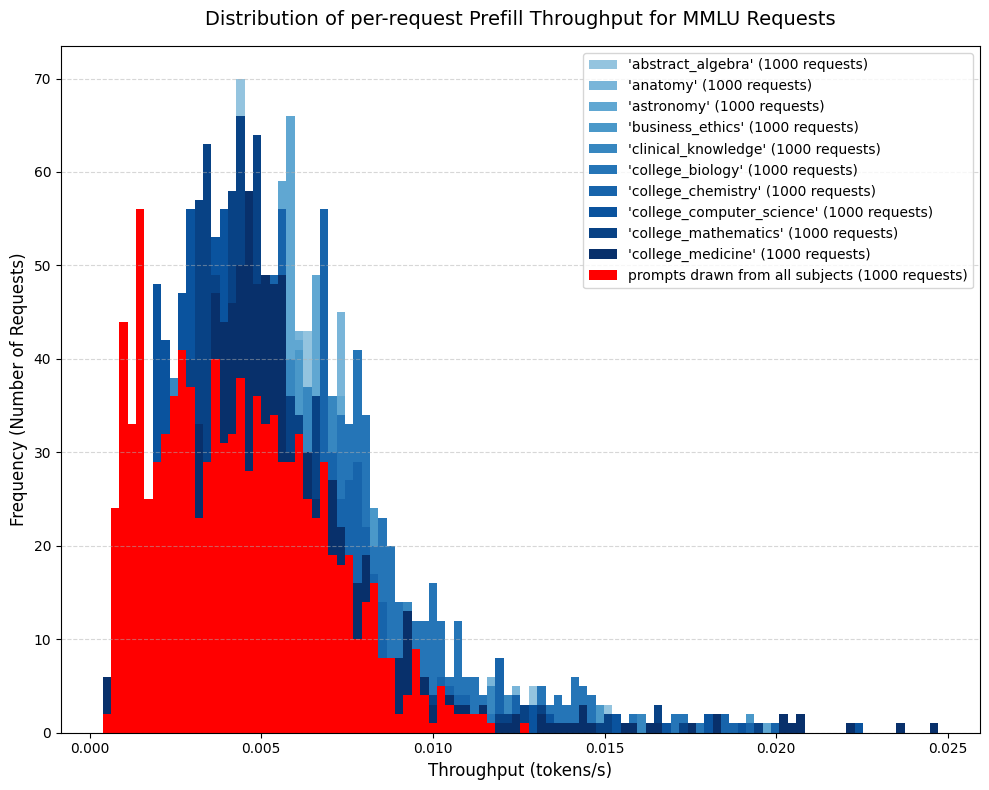

In [9]:
# Plot
plot_hist_prefill_throughput(overall_results, subject_results, x_limits=(0,1000))

In [10]:
# Run experiment for exact same prompt n_samples times
repeat_results = {}
for i in range(n_repeat_prompts):
    repeat_prompts = [mmlu_prompts[i]] * n_samples
    results, avg_tpot = await run_experiment_vllm_throughput(model,
                                                             repeat_prompts,
                                                             seed=seed,
                                                             max_new_tokens=max_new_tokens,
                                                             max_model_len=max_model_len,
                                                             batch_size=batch_size,
                                                             concurrency_limit=batch_size*4,
                                                             gpu_memory_utilization=gpu_memory_utilization,
                                                             n_gpus=n_gpus,
                                                             n_warmup_samples=n_warmup_samples,
                                                             print_output=False,
                                                             enable_expert_parallel=enable_expert_parallel)
    repeat_results[f"repeat prompt {i}"] = results

Starting vLLM server for deepseek-ai/DeepSeek-V2-Lite-Chat...
Waiting for server to initialize ...
(APIServer pid=59840) INFO 06-08 13:14:28 [utils.py:344] 
(APIServer pid=59840) INFO 06-08 13:14:28 [utils.py:344]        █     █     █▄   ▄█
(APIServer pid=59840) INFO 06-08 13:14:28 [utils.py:344]  ▄▄ ▄█ █     █     █ ▀▄▀ █  version 0.22.1
(APIServer pid=59840) INFO 06-08 13:14:28 [utils.py:344]   █▄█▀ █     █     █     █  model   deepseek-ai/DeepSeek-V2-Lite-Chat
(APIServer pid=59840) INFO 06-08 13:14:28 [utils.py:344]    ▀▀  ▀▀▀▀▀ ▀▀▀▀▀ ▀     ▀
(APIServer pid=59840) INFO 06-08 13:14:28 [utils.py:344] 
(APIServer pid=59840) INFO 06-08 13:14:28 [utils.py:278] non-default args: {'model_tag': 'deepseek-ai/DeepSeek-V2-Lite-Chat', 'model': 'deepseek-ai/DeepSeek-V2-Lite-Chat', 'seed': 43, 'max_model_len': 4096, 'override_generation_config': {'temperature': 0.0}, 'tensor_parallel_size': 4, 'enable_expert_parallel': True, 'gpu_memory_utilization': 0.85, 'enable_prefix_caching': False, 'max_num

(APIServer pid=59840) Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.


(APIServer pid=59840) INFO 06-08 13:14:29 [model.py:617] Resolved architecture: DeepseekV2ForCausalLM
(APIServer pid=59840) INFO 06-08 13:14:29 [model.py:1752] Using max model len 4096
(APIServer pid=59840) INFO 06-08 13:14:29 [vllm.py:977] Asynchronous scheduling is enabled.
(APIServer pid=59840) INFO 06-08 13:14:29 [kernel.py:270] Final IR op priority after setting platform defaults: IrOpPriorityConfig(rms_norm=['native'], fused_add_rms_norm=['native'])
(EngineCore pid=60071) INFO 06-08 13:14:36 [core.py:112] Initializing a V1 LLM engine (v0.22.1) with config: model='deepseek-ai/DeepSeek-V2-Lite-Chat', speculative_config=None, tokenizer='deepseek-ai/DeepSeek-V2-Lite-Chat', skip_tokenizer_init=False, tokenizer_mode=auto, revision=None, tokenizer_revision=None, trust_remote_code=False, dtype=torch.bfloat16, max_seq_len=4096, download_dir=None, load_format=auto, tensor_parallel_size=4, pipeline_parallel_size=1, data_parallel_size=1, decode_context_parallel_size=1, dcp_comm_backend=ag_rs

(Worker_TP0_EP0 pid=60275) Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.
(Worker_TP2_EP2 pid=60277) Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.
(Worker_TP3_EP3 pid=60278) Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.
(Worker_TP1_EP1 pid=60276) Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.
Loading safetensors checkpoint shards:   0% Completed | 0/4 [00:00<?, ?it/s]


(Worker_TP0_EP0 pid=60275) INFO 06-08 13:14:46 [weight_utils.py:922] Filesystem type for checkpoints: OVERLAY. Checkpoint size: 29.26 GiB. Available RAM: 174.95 GiB.
(Worker_TP0_EP0 pid=60275) INFO 06-08 13:14:46 [weight_utils.py:945] Auto-prefetch is disabled because the filesystem (OVERLAY) is not a recognized network FS (NFS/Lustre). If you want to force prefetching, start vLLM with --safetensors-load-strategy=prefetch.


...

(APIServer pid=71118) INFO:     Started server process [71118]
(APIServer pid=71118) INFO:     Waiting for application startup.
(APIServer pid=71118) INFO:     Application startup complete.


(APIServer pid=71118) INFO:     127.0.0.1:44516 - "GET /v1/models HTTP/1.1" 200 OK
Server is ready!
Sending batch of 10 concurrent requests...
(APIServer pid=71118) INFO:     127.0.0.1:44526 - "POST /v1/chat/completions HTTP/1.1" 200 OK
(APIServer pid=71118) INFO:     127.0.0.1:44536 - "POST /v1/chat/completions HTTP/1.1" 200 OK
(APIServer pid=71118) INFO:     127.0.0.1:44542 - "POST /v1/chat/completions HTTP/1.1" 200 OK
(APIServer pid=71118) INFO:     127.0.0.1:44554 - "POST /v1/chat/completions HTTP/1.1" 200 OK
(APIServer pid=71118) INFO:     127.0.0.1:44558 - "POST /v1/chat/completions HTTP/1.1" 200 OK
(APIServer pid=71118) INFO:     127.0.0.1:44564 - "POST /v1/chat/completions HTTP/1.1" 200 OK
(APIServer pid=71118) INFO:     127.0.0.1:44574 - "POST /v1/chat/completions HTTP/1.1" 200 OK
(APIServer pid=71118) INFO:     127.0.0.1:44582 - "POST /v1/chat/completions HTTP/1.1" 200 OK
(APIServer pid=71118) INFO:     127.0.0.1:44596 - "POST /v1/chat/completions HTTP/1.1" 200 OK
(APIServer 

(APIServer pid=71118) INFO:     Shutting down
(APIServer pid=71118) INFO:     Waiting for application shutdown.
(APIServer pid=71118) INFO:     Application shutdown complete.


Server successfully shut down.


/usr/lib/python3.11/multiprocessing/resource_tracker.py:254: UserWarning: resource_tracker: There appear to be 4 leaked semaphore objects to clean up at shutdown
  warnings.warn('resource_tracker: There appear to be %d '
/usr/lib/python3.11/multiprocessing/resource_tracker.py:254: UserWarning: resource_tracker: There appear to be 6 leaked shared_memory objects to clean up at shutdown
  warnings.warn('resource_tracker: There appear to be %d '


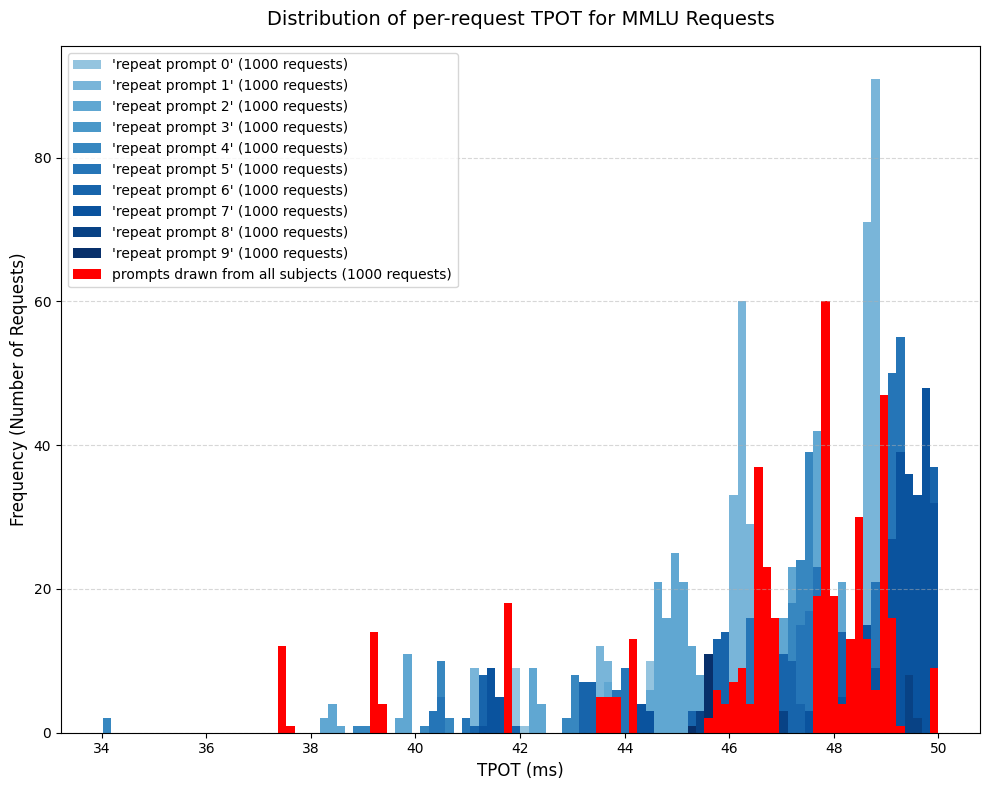

In [11]:
plot_hist_tpots(overall_results, repeat_results)

In [12]:
import pickle
with open(f'./vllm_benchmarking/overall_results_gpu{n_gpus}_batch{batch_size}_samples{n_samples}_expertp_cache.pkl', 'wb') as file:
    pickle.dump(overall_results, file)
with open(f'./vllm_benchmarking/subject_results_gpu{n_gpus}_batch{batch_size}_samples{n_samples}_expertp_cache.pkl', 'wb') as file:
    pickle.dump(subject_results, file)
with open(f'./vllm_benchmarking/repeat_results_gpu{n_gpus}_batch{batch_size}_samples{n_samples}_expertp_cache.pkl', 'wb') as file:
    pickle.dump(repeat_results, file)